
[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Processing...
Done!


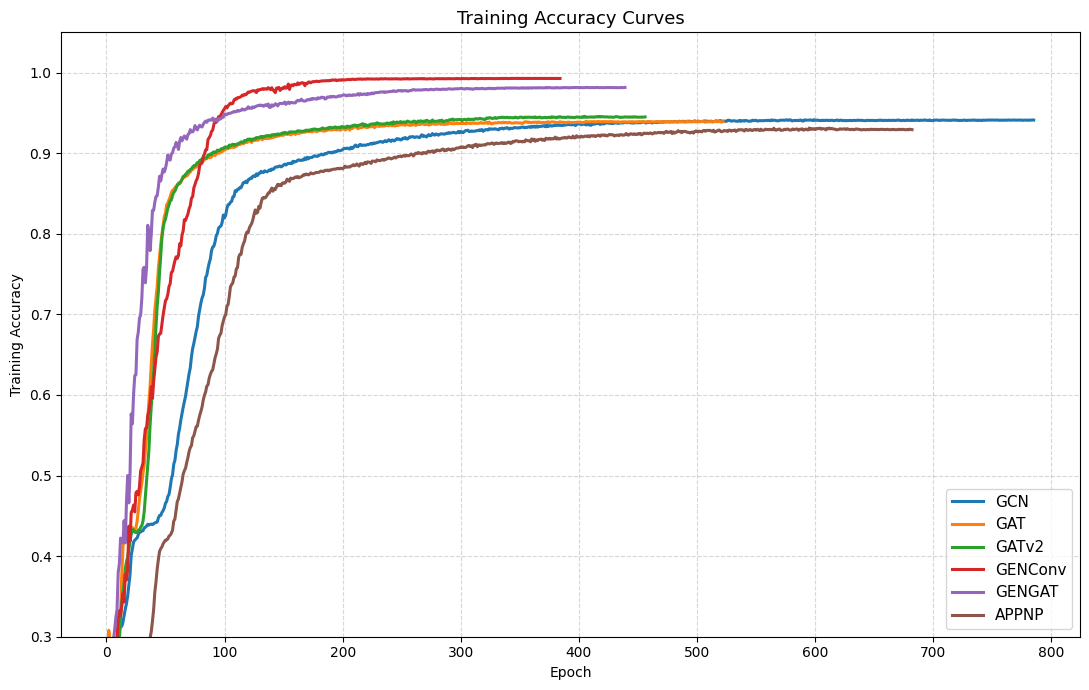

In [1]:
!pip install torch_geometric
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Amazon
from torch_geometric.utils import to_undirected, add_self_loops
from torch_geometric.nn import GCNConv, GATConv, GATv2Conv, GENConv, APPNP, MessagePassing
from torch_geometric.utils import softmax
import torch_geometric.transforms as T

import os
import random
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
hidden_dim = 64
dropout = 0.5
lr = 0.01
weight_decay = 1e-4
patience = 100
max_epochs = 2000
num_runs = 10
base_seed = 42
grad_clip_norm = 1.0
scheduler_patience = 50
scheduler_factor = 0.5
min_lr = 1e-5

# ── Custom GAT + GENConv layer ──
class GENGATConv(MessagePassing):
    def __init__(self, in_channels, out_channels, heads=4, concat=True, dropout=0.5):
        super().__init__(aggr='add', node_dim=0)
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.heads = heads
        self.concat = concat
        self.dropout = dropout
        self.lin = nn.Linear(in_channels, heads * out_channels, bias=True)
        self.attn = nn.Parameter(torch.Tensor(heads, 2 * out_channels, 1))
        self.leaky_relu = nn.LeakyReLU(0.2)
        mlp_in = heads * out_channels if concat else out_channels
        self.mlp = nn.Sequential(nn.Linear(mlp_in, mlp_in), nn.ReLU(), nn.Linear(mlp_in, mlp_in))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin.weight, gain=1.414)
        nn.init.zeros_(self.lin.bias)
        nn.init.xavier_uniform_(self.attn, gain=1.414)

    def forward(self, x, edge_index):
        x_transformed = self.lin(x)
        aggr_out = self.propagate(edge_index, x=x_transformed)
        return self.mlp(aggr_out) + x_transformed

    def message(self, x_i, x_j, index):
        x_i = x_i.view(-1, self.heads, self.out_channels)
        x_j = x_j.view(-1, self.heads, self.out_channels)
        attn_input = torch.cat([x_i, x_j], dim=-1)
        e = torch.einsum('ehd,hdo->eh', attn_input, self.attn)
        e = self.leaky_relu(e)
        alpha = softmax(e, index)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        out = alpha.unsqueeze(-1) * x_j
        return out.reshape(-1, self.heads * self.out_channels)

    def update(self, aggr_out):
        if self.concat:
            return aggr_out
        return aggr_out.reshape(-1, self.heads, self.out_channels).mean(dim=1)

# ── Model definitions ──
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=dropout, training=self.training)
        return self.conv2(x, edge_index)

class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=4, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * 4, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=dropout, training=self.training)
        return self.conv2(x, edge_index)

class GATv2(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=4, dropout=dropout)
        self.conv2 = GATv2Conv(hidden_channels * 4, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=dropout, training=self.training)
        return self.conv2(x, edge_index)

class GENConvNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GENConv(in_channels, hidden_channels, aggr='softmax', t=1.0, learn_t=True, num_layers=2, norm='layer')
        self.conv2 = GENConv(hidden_channels, out_channels, aggr='softmax', t=1.0, learn_t=True, num_layers=2, norm='layer')

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=dropout, training=self.training)
        return self.conv2(x, edge_index)

class GENGATNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GENGATConv(in_channels, hidden_channels, heads=4, concat=True, dropout=dropout)
        self.conv2 = GENGATConv(hidden_channels * 4, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=dropout, training=self.training)
        return self.conv2(x, edge_index)

class APPNPNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, K=10, alpha=0.1):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)
        self.prop = APPNP(K=K, alpha=alpha)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=dropout, training=self.training)
        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=dropout, training=self.training)
        x = self.lin2(x)
        return self.prop(x, edge_index)

# ── Utilities ──
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ── Load dataset ──
root = os.getcwd()
dataset = Amazon(root, name='Photo', transform=T.NormalizeFeatures())
original_data = dataset[0]
original_data.edge_index = to_undirected(original_data.edge_index)
original_data.edge_index, _ = add_self_loops(original_data.edge_index, num_nodes=original_data.num_nodes)

in_channels = dataset.num_features
out_channels = dataset.num_classes

# ── Training (returns only train history) ──
def train_one_run(data, model):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=scheduler_factor,
        patience=scheduler_patience, min_lr=min_lr
    )

    best_val_acc = 0.0
    counter = 0
    train_acc_history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
        optimizer.step()

        with torch.no_grad():
            pred = out.argmax(dim=1)
            train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()
            train_acc_history.append(train_acc)

        model.eval()
        with torch.no_grad():
            out_eval = model(data.x, data.edge_index)
            pred_eval = out_eval.argmax(dim=1)
            val_acc = (pred_eval[data.val_mask] == data.y[data.val_mask]).float().mean().item()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                break

        scheduler.step(val_acc)

    return train_acc_history

# ── Run all models ──
models = [
    ('GCN', GCN),
    ('GAT', GAT),
    ('GATv2', GATv2),
    ('GENConv', GENConvNet),
    ('GENGAT', GENGATNet),
    ('APPNP', APPNPNet),
]

all_train_histories = {}

for model_name, model_class in models:
    histories = []
    for run in range(1, num_runs + 1):
        set_seed(base_seed + run - 1)
        data = original_data.clone()
        data = T.RandomNodeSplit(split='train_rest', num_val=0.10, num_test=0.10)(data)
        data = data.to(device)
        model = model_class(in_channels, hidden_dim, out_channels).to(device)
        histories.append(train_one_run(data, model))
    all_train_histories[model_name] = histories

# ── Plot only training curves ──
plt.figure(figsize=(11, 7))

for model_name, histories in all_train_histories.items():
    max_len = max(len(h) for h in histories)
    padded = np.array([h + [h[-1]] * (max_len - len(h)) for h in histories])
    mean_curve = np.mean(padded, axis=0)
    plt.plot(np.arange(1, max_len + 1), mean_curve, label=model_name, linewidth=2.2)

plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy Curves', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=11)
plt.ylim(0.3, 1.05)
plt.tight_layout()
plt.show()


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Processing...
Done!


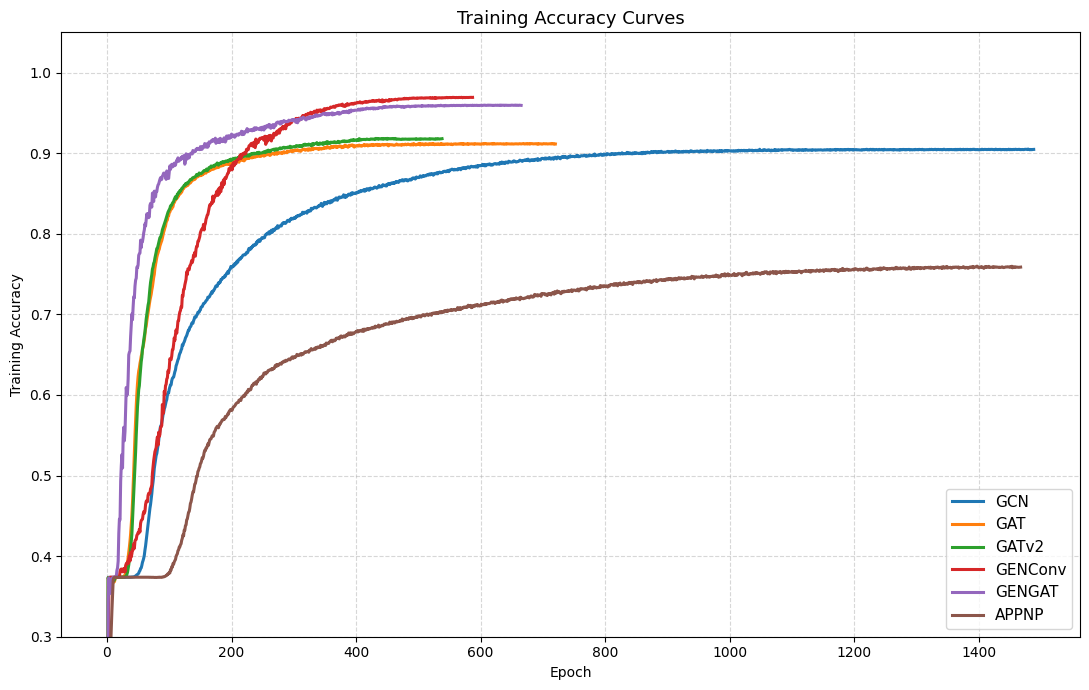

In [1]:
!pip install torch_geometric
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Amazon
from torch_geometric.utils import to_undirected, add_self_loops
from torch_geometric.nn import GCNConv, GATConv, GATv2Conv, GENConv, APPNP, MessagePassing
from torch_geometric.utils import softmax
import torch_geometric.transforms as T

import os
import random
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
hidden_dim = 64
dropout = 0.5
lr = 0.01
weight_decay = 1e-4
patience = 100
max_epochs = 2000
num_runs = 10
base_seed = 42
grad_clip_norm = 1.0
scheduler_patience = 50
scheduler_factor = 0.5
min_lr = 1e-5

# ── Custom GAT + GENConv layer ──
class GENGATConv(MessagePassing):
    def __init__(self, in_channels, out_channels, heads=4, concat=True, dropout=0.5):
        super().__init__(aggr='add', node_dim=0)
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.heads = heads
        self.concat = concat
        self.dropout = dropout
        self.lin = nn.Linear(in_channels, heads * out_channels, bias=True)
        self.attn = nn.Parameter(torch.Tensor(heads, 2 * out_channels, 1))
        self.leaky_relu = nn.LeakyReLU(0.2)
        mlp_in = heads * out_channels if concat else out_channels
        self.mlp = nn.Sequential(nn.Linear(mlp_in, mlp_in), nn.ReLU(), nn.Linear(mlp_in, mlp_in))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin.weight, gain=1.414)
        nn.init.zeros_(self.lin.bias)
        nn.init.xavier_uniform_(self.attn, gain=1.414)

    def forward(self, x, edge_index):
        x_transformed = self.lin(x)
        aggr_out = self.propagate(edge_index, x=x_transformed)
        return self.mlp(aggr_out) + x_transformed

    def message(self, x_i, x_j, index):
        x_i = x_i.view(-1, self.heads, self.out_channels)
        x_j = x_j.view(-1, self.heads, self.out_channels)
        attn_input = torch.cat([x_i, x_j], dim=-1)
        e = torch.einsum('ehd,hdo->eh', attn_input, self.attn)
        e = self.leaky_relu(e)
        alpha = softmax(e, index)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        out = alpha.unsqueeze(-1) * x_j
        return out.reshape(-1, self.heads * self.out_channels)

    def update(self, aggr_out):
        if self.concat:
            return aggr_out
        return aggr_out.reshape(-1, self.heads, self.out_channels).mean(dim=1)

# ── Model definitions ──
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=dropout, training=self.training)
        return self.conv2(x, edge_index)

class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=4, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * 4, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=dropout, training=self.training)
        return self.conv2(x, edge_index)

class GATv2(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=4, dropout=dropout)
        self.conv2 = GATv2Conv(hidden_channels * 4, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=dropout, training=self.training)
        return self.conv2(x, edge_index)

class GENConvNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GENConv(in_channels, hidden_channels, aggr='softmax', t=1.0, learn_t=True, num_layers=2, norm='layer')
        self.conv2 = GENConv(hidden_channels, out_channels, aggr='softmax', t=1.0, learn_t=True, num_layers=2, norm='layer')

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=dropout, training=self.training)
        return self.conv2(x, edge_index)

class GENGATNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GENGATConv(in_channels, hidden_channels, heads=4, concat=True, dropout=dropout)
        self.conv2 = GENGATConv(hidden_channels * 4, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=dropout, training=self.training)
        return self.conv2(x, edge_index)

class APPNPNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, K=10, alpha=0.1):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)
        self.prop = APPNP(K=K, alpha=alpha)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=dropout, training=self.training)
        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=dropout, training=self.training)
        x = self.lin2(x)
        return self.prop(x, edge_index)

# ── Utilities ──
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ── Load dataset ──
root = os.getcwd()
dataset = Amazon(root, name='Computers', transform=T.NormalizeFeatures())
original_data = dataset[0]
original_data.edge_index = to_undirected(original_data.edge_index)
original_data.edge_index, _ = add_self_loops(original_data.edge_index, num_nodes=original_data.num_nodes)

in_channels = dataset.num_features
out_channels = dataset.num_classes

# ── Training (returns only train history) ──
def train_one_run(data, model):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=scheduler_factor,
        patience=scheduler_patience, min_lr=min_lr
    )

    best_val_acc = 0.0
    counter = 0
    train_acc_history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
        optimizer.step()

        with torch.no_grad():
            pred = out.argmax(dim=1)
            train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()
            train_acc_history.append(train_acc)

        model.eval()
        with torch.no_grad():
            out_eval = model(data.x, data.edge_index)
            pred_eval = out_eval.argmax(dim=1)
            val_acc = (pred_eval[data.val_mask] == data.y[data.val_mask]).float().mean().item()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                break

        scheduler.step(val_acc)

    return train_acc_history

# ── Run all models ──
models = [
    ('GCN', GCN),
    ('GAT', GAT),
    ('GATv2', GATv2),
    ('GENConv', GENConvNet),
    ('GENGAT', GENGATNet),
    ('APPNP', APPNPNet),
]

all_train_histories = {}

for model_name, model_class in models:
    histories = []
    for run in range(1, num_runs + 1):
        set_seed(base_seed + run - 1)
        data = original_data.clone()
        data = T.RandomNodeSplit(split='train_rest', num_val=0.10, num_test=0.10)(data)
        data = data.to(device)
        model = model_class(in_channels, hidden_dim, out_channels).to(device)
        histories.append(train_one_run(data, model))
    all_train_histories[model_name] = histories

# ── Plot only training curves ──
plt.figure(figsize=(11, 7))

for model_name, histories in all_train_histories.items():
    max_len = max(len(h) for h in histories)
    padded = np.array([h + [h[-1]] * (max_len - len(h)) for h in histories])
    mean_curve = np.mean(padded, axis=0)
    plt.plot(np.arange(1, max_len + 1), mean_curve, label=model_name, linewidth=2.2)

plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy Curves', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=11)
plt.ylim(0.3, 1.05)
plt.tight_layout()
plt.show()